# BMesonsML — XGBoost emulator of the SMEFT19 likelihood (rotBIII / Scenario III)

This notebook builds a fast **XGBoost surrogate** of the SMEFT19 global-fit
log-likelihood in the rotBIII (Scenario III) direction — the 3D space of Wilson
coefficients `(C1, C3, βq)` — and uses it to reproduce the B-physics figures of
the paper at a tiny fraction of the cost of evaluating SMEFT19 directly.

**Pipeline:**
1. **Dataset** (§1): Sobol global coverage + a covariance-based cloud around the
   best fit + three 2D plane grids, each point evaluated with SMEFT19 and cached
   on disk (regenerated only if missing or `FORCE_REBUILD=True`), plus an
   **active-learning densification** of the sparse high-βq region
   (`FORCE_DENSIFY`) that fixes the Fig 7b spike.
2. **Preprocessing** (§2): filter by likelihood, EDA, and an 84/16 train/val
   split (no SMOTE — see §2 for why).
3. **Training** (§3): XGBoost with early stopping + learning curve.
4. **SHAP** (§4): beeswarm, bar, waterfall and dependence plots.
5. **Save** (§5): persist the trained surrogate to disk.
6. **Paper figures** (§6–§8): Fig 7 (χ² validation + Monte-Carlo Δχ²
   distribution), Fig 11 (Pearson correlation matrix of the flavour
   observables; the WET-coefficient matrix of the old Fig 10 was dropped from
   the paper), and the ML speed-up benchmark (Fig 8).

## Setup (run first)

Paths, caching flags (`FORCE_REBUILD`, `FORCE_RETRAIN`, `FORCE_DENSIFY`), the
paper plotting style, the physical domain of `(C1, C3, βq)` and the CPU/GPU
configuration. `FORCE_DENSIFY` controls the high-βq active-learning
densification step of §1 (see the markdown there).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time, csv, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBRegressor, callback as xgb_cb

# Large serif (Palatino/mathpazo) + LaTeX when available; mathtext fallback otherwise.
import shutil as _shutil
_USETEX = bool(_shutil.which('latex') and _shutil.which('dvipng'))

def _apply_paper_style():
    """Paper figure style (big serif). Re-call after SMEFT19/flavio imports,
    which overwrite the matplotlib rc params."""
    plt.rcParams['text.usetex'] = _USETEX
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype',
                                   'URW Palladio L', 'DejaVu Serif']
    plt.rcParams['mathtext.fontset'] = 'cm'   # used only when usetex is off
    if _USETEX:
        plt.rcParams['text.latex.preamble'] = r'\usepackage{mathpazo}'
    plt.rcParams.update({
        'font.size': 15, 'axes.titlesize': 18, 'axes.labelsize': 17,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.titlesize': 19,
    })

_apply_paper_style()

# Paths
ROOT     = Path('..')
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs'

DATASET_FILE = DATA_DIR / 'combined_rotBIII_2025.dat'
BESTFIT_FILE = DATA_DIR / 'rotBIII_2025.yaml'
MODEL_OUT    = OUT_DIR  / 'xgboost_scIII.json'
FIGS_DIR     = OUT_DIR  / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Flags
FORCE_REBUILD  = False
FORCE_RETRAIN  = False
BEST_PARAMS_FILE = OUT_DIR / 'best_params_rotBIII.json'

# High-bq densification (active-learning fix for the Fig 7b spike; see section 1
# markdown). Slow but resumable; needs the SMEFT19 env (.venv-paper).
FORCE_DENSIFY   = True
N_EXTRA_DENSIFY = 12000   # total high-bq SMEFT19 points (resumes the existing extra file)
BQ_LO_DENSIFY   = 1.5     # lower bq edge of the densified slab

# Dataset layout (generation lives in scripts/regenerate_dataset.py)
GRID_SIZE   = 40     # each 2D plane grid is GRID_SIZE x GRID_SIZE
SEED        = 42

# CPU parallelism (SMEFT19 is CPU-only)
N_WORKERS_OVERRIDE = None   # set an int (e.g. 16) to cap; None = all cores
N_WORKERS = N_WORKERS_OVERRIDE or max(1, multiprocessing.cpu_count() - 1)

# XGBoost device
def _detect_xgb_device():
    """Return 'cuda' if XGBoost can use the GPU here, else 'cpu'."""
    try:
        import xgboost as xgb
        dm = xgb.DMatrix(np.zeros((10, 3)), label=np.zeros(10))
        xgb.train({'device': 'cuda', 'tree_method': 'hist'}, dm,
                  num_boost_round=1, verbose_eval=False)
        return 'cuda'
    except Exception:
        return 'cpu'

# The CUDA build here trains poorly (R2~0.5); CPU is correct and fast
XGB_DEVICE = 'cpu'

# Physical domain
C1_RANGE  = (-0.30,  0.00)
C3_RANGE  = (-0.30,  0.00)
BQ_RANGE  = ( 0.00,  3.20)
LH_MIN    = -50.0
N_DOF     = 3   # free parameters: C1, C3, bq

print(f'Dataset: {DATASET_FILE}')
print(f'Outputs: {OUT_DIR}')
print(f'Grids  : 3×{GRID_SIZE}²={3*GRID_SIZE**2} plane-grid rows at the end of the dataset (Fig 8a)')
print(f'Workers: {N_WORKERS} CPUs  |  XGBoost device: {XGB_DEVICE}')

Dataset: ../data/combined_rotBIII_2025.dat
Outputs: ../outputs
Points : 3000 random + 3×40²=4800 grid = 7800 total
Workers: 23 CPUs  |  XGBoost device: cpu


## 1. Dataset — generation or load

The dataset `(C1, C3, βq, logL)` is produced by `scripts/regenerate_dataset.py`
(after `scripts/refit_bestfit.py` writes the best fit to `rotBIII_2025.yaml`).
Each point's log-likelihood is the SMEFT19 global fit evaluated with the **2025
measurements**. It combines three complementary samplings:

- **Sobol global** (`N_SOBOL ≈ 4096`): low-discrepancy quasi-random coverage of
  the full physical cube `[C1, C3, βq]` — captures the overall likelihood shape.
- **Covariance-based cloud** (`N_LOCAL ≈ 5000`): Gaussian samples drawn with the
  fit covariance Σ around the best fit, as a two-scale mix (tight core + broad
  shoulder). Because it follows the actual likelihood ellipsoid it automatically
  densifies the narrow `C1` ridge **without** a hand-tuned grid.
- **Three 2D plane grids** (`GRID×GRID`, here 40×40, third parameter fixed at the
  best fit): kept only so §8 can draw the "real SMEFT19 vs emulator" 2D maps.

That is ≈ 13.9k base points. The best fit (and its covariance Σ) come from
`SMEFT19.ellipse.minimum`, cached in `data/rotBIII_2025.yaml`; this 2025 refit
supersedes the old `rotBIII.yaml`, whose stored point was a `C1 = C3` local
minimum rather than the true Scenario III best fit. Everything is cached on
disk: set `FORCE_REBUILD=True` to recompute from scratch.

### High-βq densification (active learning)

Trained on the base design alone, the emulator **over-extrapolates** logL in the
data-sparse high-βq corner: it invents a false maximum (logL ≈ 25–26 where the
true SMEFT19 value is ≈ 20–22). That false maximum produced a spike at 0 in the
Fig 7b Δχ² histogram and biased the high-βq part of the MCMC posterior. The fix
is pure active learning: evaluate real SMEFT19 labels in that slab
(`scripts/densify_highbq.py`, ~12k extra points streamed to
`data/extra_highbq_2025.dat`, resumable), splice them into the dataset keeping
the plane grids last (so the Fig 8a slicing is unchanged), and retrain. The
emulator still drives everything; it is simply trained on better data, bringing
the total to ≈ 26k points. Set `FORCE_DENSIFY=False` in Setup to skip this step.

> The cells below (re)generate or load the dataset and report how many points are
> valid (`likelihood > LH_MIN`). The old hand-tuned dense `C1` grid is no longer
> needed — the covariance cloud already resolves the `C1` ridge.

In [2]:
# (Re)build the best-fit + dataset with the 2025 measurements, or load the cache.
# Heavy logic lives in scripts/. Set FORCE_REBUILD=True to redo it.
if FORCE_REBUILD or not BESTFIT_FILE.exists() or not DATASET_FILE.exists():
    import sys
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    from setup_likelihood import setup_global_likelihood
    from refit_bestfit import refit_bestfit
    from regenerate_dataset import regenerate
    setup_global_likelihood()                            # build the likelihood once
    if FORCE_REBUILD or not BESTFIT_FILE.exists():
        refit_bestfit(BESTFIT_FILE, setup=False)         # -> data/rotBIII_2025.yaml
    regenerate(DATASET_FILE, BESTFIT_FILE, setup=False)  # -> data/combined_rotBIII_2025.dat
else:
    print('Loading cached dataset + best-fit')

df_raw = pd.read_csv(DATASET_FILE, names=['C1', 'C3', 'bq', 'likelihood'])
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Total points: {len(df_raw)}  |  valid (lh > {LH_MIN}): {n_valid}')
df_raw.describe()

# SMEFT19 overwrites the rc params on import; re-apply the paper style.
_apply_paper_style()

Loading cached dataset + best-fit
Total points: 13896  |  valid (lh > -50.0): 11614


In [3]:
# The covariance-based sampling resolves the narrow C1 ridge, so no extra dense grid is needed.
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Dataset: {len(df_raw)} pts  |  valid: {n_valid}')

Dataset: 13896 pts  |  valid: 11614


In [4]:
# High-bq densification (see section 1 markdown): add real SMEFT19 labels in the
# sparse high-bq slab, splice them in (plane grids stay last) and retrain.
# Resumable: streams to data/extra_highbq_2025.dat. Needs .venv-paper.
if FORCE_DENSIFY:
    import os, sys, importlib
    os.environ['N_EXTRA']   = str(N_EXTRA_DENSIFY)
    os.environ['BQ_LO']     = str(BQ_LO_DENSIFY)
    os.environ['N_WORKERS'] = str(N_WORKERS)
    os.environ.setdefault('EVAL_TIMEOUT', '30')
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    import densify_highbq
    importlib.reload(densify_highbq)        # re-read N_EXTRA/BQ_LO from os.environ
    densify_highbq.main()                   # evaluate (resumable) + rebuild the dataset

    df_raw = pd.read_csv(DATASET_FILE, names=['C1', 'C3', 'bq', 'likelihood'])
    _apply_paper_style()                    # SMEFT19 import overwrites rc params
    n_valid = (df_raw['likelihood'] > LH_MIN).sum()
    print(f'Densified dataset: {len(df_raw)} pts  |  valid (lh > {LH_MIN}): {n_valid}')
else:
    print('FORCE_DENSIFY=False -> using the dataset as-is')

densifying slab C1(-0.3, 0.0) x C3(-0.3, 0.0) x bq[1.5, 3.2] with 12000 SMEFT19 points (seed=202)
resuming from 3584/12000
building global likelihood in parent (inherited by workers via fork)...
global likelihood configured with measurements_2025.yml (+ R(J/psi) term)
  4000/12000 | 601s | ETA 11548s
  4500/12000 | 907s | ETA 7428s
  5000/12000 | 1195s | ETA 5910s
  5500/12000 | 1785s | ETA 6057s
  6000/12000 | 2092s | ETA 5195s
  6500/12000 | 2375s | ETA 4480s
  7000/12000 | 2900s | ETA 4245s
  7500/12000 | 3187s | ETA 3662s
  8000/12000 | 3463s | ETA 3137s
  8500/12000 | 3978s | ETA 2832s
  9000/12000 | 4290s | ETA 2376s
  9500/12000 | 4861s | ETA 2054s
  10000/12000 | 5158s | ETA 1608s
  10500/12000 | 5455s | ETA 1183s
  11000/12000 | 5956s | ETA 803s
  11500/12000 | 6288s | ETA 397s
  12000/12000 | 6539s | ETA 0s

extra evaluations done in 6539s -> extra_highbq_2025.dat
snapshot of original dataset -> combined_rotBIII_2025.dat.orig

rebuilt combined_rotBIII_2025.dat: 9096 body + 12

## 2. Preprocessing

Keep only physical points (`likelihood > LH_MIN`), run a quick EDA (2D scatter of
the three coefficient pairs colored by logL), and make an **84/16 train/validation
split**.

**No SMOTE.** Oversampling was tried and removed: SMOTE interpolates the features
of medium-likelihood points into regions where the true likelihood is high and
then assigns them KNN labels (~17) where the real value is ~30. That creates
contradictory labels near the peak and degrades the emulator exactly where it
matters most. The covariance-based sampling of §1 already densifies the peak, so
no synthetic oversampling is needed.

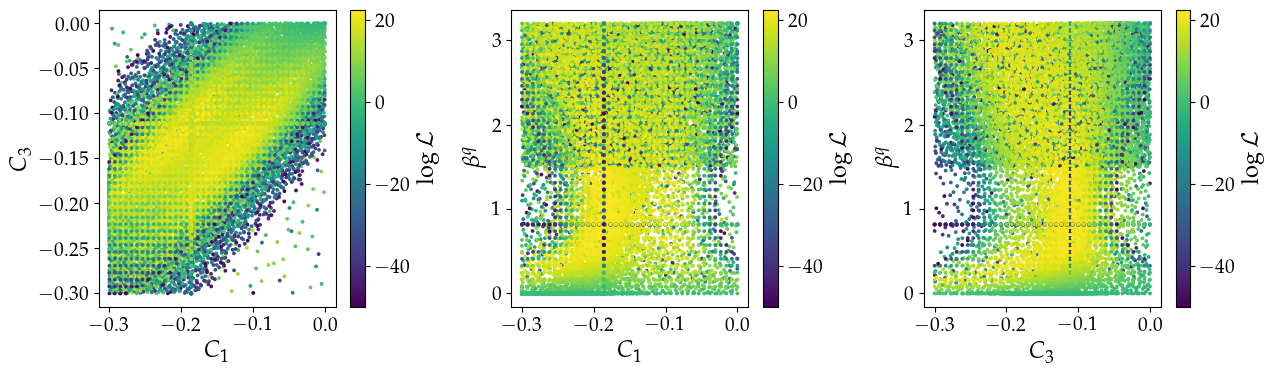

Train: 15154  |  Validation: 2887


In [5]:
df = df_raw[df_raw['likelihood'] > LH_MIN].reset_index(drop=True).copy()

# EDA
pairs   = [('C1', 'C3'), ('C1', 'bq'), ('C3', 'bq')]
xlabels = [r'$C_1$', r'$C_1$', r'$C_3$']
ylabels = [r'$C_3$', r'$\beta^q$', r'$\beta^q$']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
    sc = ax.scatter(df[xc], df[yc], c=df['likelihood'], cmap='viridis', s=3, rasterized=True)
    plt.colorbar(sc, ax=ax, label=r'$\log\mathcal{L}$')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'eda_scatter.pdf', bbox_inches='tight')
plt.show()

X, y = df[['C1', 'C3', 'bq']], df['likelihood']

# 84/16 train/validation split
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.16, random_state=SEED)

# No SMOTE: it assigns KNN labels (~17) where the true likelihood is high (~30),
# creating contradictory labels near the peak and degrading the model there.
Xtr_res, ytr_res = Xtr, ytr

print(f'Train: {len(Xtr)}  |  Validation: {len(Xva)}')

## 3. XGBoost training

Gradient-boosted trees regressing `logL` on `(C1, C3, βq)`. The hyperparameters
are the ones validated in the original notebook (`learning_rate=0.03`,
`max_depth=6`, `n_estimators=3000`), trained with **early stopping** (5 rounds on
the validation RMSE) and a learning curve. The fitted model is cached to
`outputs/xgboost_scIII.json`; with `FORCE_RETRAIN=False` it is reloaded instead of
refit.

In [6]:
# XGBoost hyperparameters (validated earlier, RMSE=2.1)
best_xgb_params = dict(
    learning_rate    = 0.03,
    max_depth        = 6,
    min_child_weight = 1,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    gamma            = 0.0,
    reg_alpha        = 0.0,
    reg_lambda       = 1.0,
)
print('Hyperparameters:')
for k, v in best_xgb_params.items():
    print(f'  {k}: {v}')

Hyperparameters:
  learning_rate: 0.03
  max_depth: 6
  min_child_weight: 1
  subsample: 1.0
  colsample_bytree: 1.0
  gamma: 0.0
  reg_alpha: 0.0
  reg_lambda: 1.0


R2 = 0.98391  |  MAE = 0.9269  |  best_iter = 2999  |  device = cpu
  saved: ../outputs/figures/learning_curve.pdf


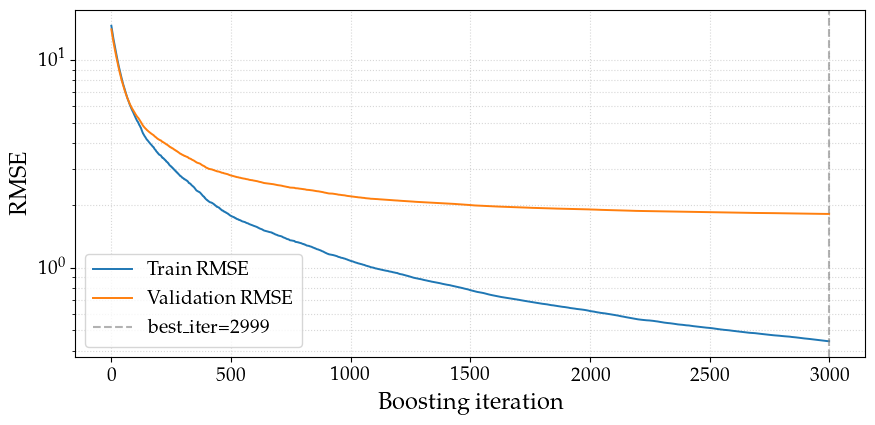

In [7]:
def _plot_learning_curve(info, title='', show=True, save_path=None):
    er     = info['eval_results']
    metric = info['eval_metric']
    keys   = list(er.keys())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(er[keys[0]][metric], label=f'Train {metric.upper()}', lw=1.4)
    ax.plot(er[keys[1]][metric], label=f'Validation {metric.upper()}', lw=1.4)
    if info.get('best_iteration') is not None:
        ax.axvline(info['best_iteration'], color='gray', ls='--', alpha=0.6,
                   label=f"best_iter={info['best_iteration']}")
    ax.set_yscale('log'); ax.set_xlabel('Boosting iteration'); ax.set_ylabel(metric.upper())
    ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show() if show else plt.close(fig)


if not (FORCE_RETRAIN or FORCE_DENSIFY) and MODEL_OUT.exists():
    print(f'Loading cached model: {MODEL_OUT}')
    model = XGBRegressor()
    model.load_model(str(MODEL_OUT))
    r2  = float(model.score(Xva, yva))
    mae = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  device = {XGB_DEVICE}')
    info = dict(eval_results=None, eval_metric='rmse', best_iteration=None,
                r2=r2, X_val=Xva)
else:
    _defaults = dict(n_estimators=3000, learning_rate=0.03, max_depth=6)
    _params   = {**_defaults, **(best_xgb_params if 'best_xgb_params' in dir() else {})}

    es    = xgb_cb.EarlyStopping(rounds=5, data_name='validation_1', save_best=True)
    model = XGBRegressor(
        **_params,
        tree_method='hist', device=XGB_DEVICE, eval_metric='rmse',
        random_state=SEED, callbacks=[es],
    )
    model.fit(
        Xtr_res, ytr_res,
        eval_set=[(Xtr_res, ytr_res), (Xva, yva)],
        verbose=False,
    )
    model.save_model(str(MODEL_OUT))

    r2   = float(model.score(Xva, yva))
    mae  = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    best = int(getattr(model, 'best_iteration', model.n_estimators - 1))
    info = dict(
        eval_results   = model.evals_result(),
        eval_metric    = 'rmse',
        best_iteration = best,
        r2             = r2,
        X_val          = Xva,
    )
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  best_iter = {best}  |  device = {XGB_DEVICE}')
    _plot_learning_curve(
        info,
        save_path=FIGS_DIR / 'learning_curve.pdf',
    )

## 4. SHAP analysis

Three plots (same helpers as CosmoML), computed with `TreeExplainer` on the
trained model:
1. **beeswarm + bar**: global importance of each feature.
2. **waterfall**: additive decomposition for a single sample.
3. **dependence**: effect of each feature, colored by interactions (`color=shap_values`).

In [8]:
# SHAP helpers

def _explain(model, X, n_sample=1000, seed=42):
    """TreeExplainer on the model; check_additivity=False."""
    explainer = shap.TreeExplainer(model)
    X_s = X.sample(n=min(n_sample, len(X)), random_state=seed)
    return explainer(X_s, check_additivity=False), X_s


def shap_summary(model, X, title='', save_dir=None, n_sample=1000, show=True):
    """Beeswarm + bar."""
    shap_v, X_s = _explain(model, X, n_sample=n_sample)
    _LBL = {'C1': r'$C_1$', 'C3': r'$C_3$', 'bq': r'$\beta^q$'}
    shap_v.feature_names = [_LBL.get(c, c) for c in X_s.columns]
    for kind, fn in [('beeswarm', shap.plots.beeswarm), ('bar', shap.plots.bar)]:
        plt.figure()
        fn(shap_v, show=False)
        if kind == 'bar':
            # usetex renders a bare '|' as a dash; wrap the abs-value bars in math mode.
            plt.gca().set_xlabel(r'mean($|$SHAP value$|$)')
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'shap_{kind}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()
    return shap_v, X_s


def shap_waterfall(shap_values, idx=0, title='', save_path=None, show=True):
    """Waterfall for a single sample."""
    plt.figure()
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight'); print(f'  saved: {save_path}')
    plt.show() if show else plt.close()


def shap_dependence_all(shap_values, X, save_dir=None, prefix='', show=True):
    """Per-feature dependence scatter, colored by interactions."""
    # Integer slicing: feature_names may have been relabelled to LaTeX.
    for i, col in enumerate(X.columns):
        plt.figure()
        shap.plots.scatter(shap_values[:, i], color=shap_values, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'{prefix}_shap_{col}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()

  saved: ../outputs/figures/shap_beeswarm.pdf


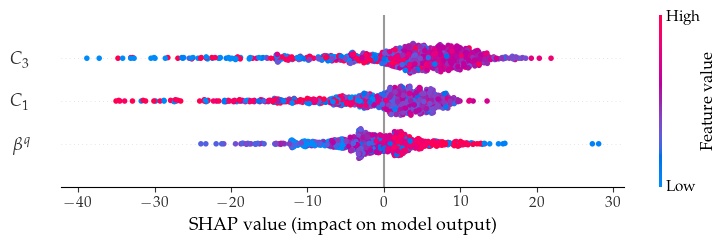

  saved: ../outputs/figures/shap_bar.pdf


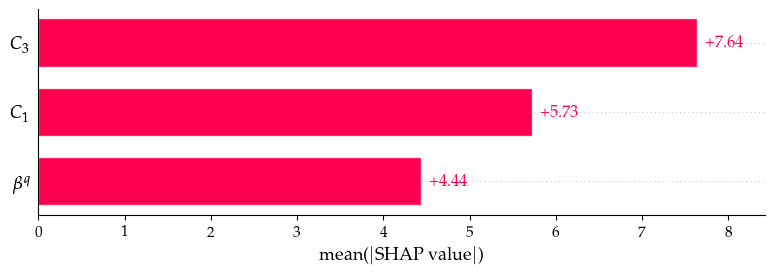

  saved: ../outputs/figures/shap_waterfall.pdf


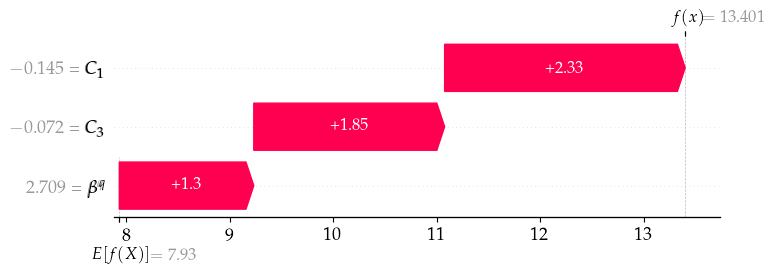

  saved: ../outputs/figures/rotBIII_shap_C1.pdf


<Figure size 640x480 with 0 Axes>

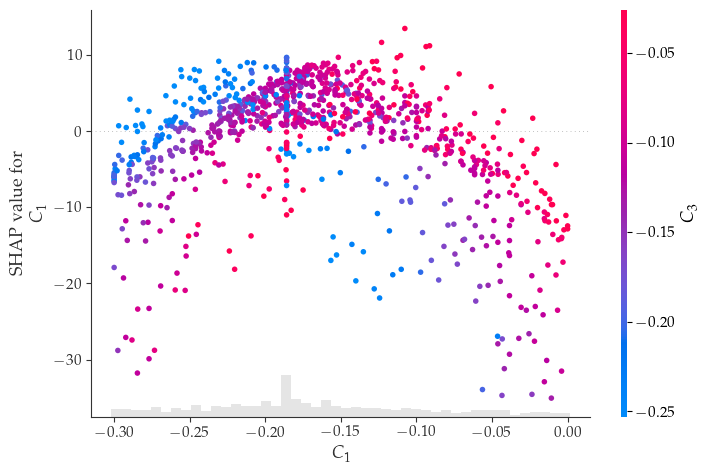

  saved: ../outputs/figures/rotBIII_shap_C3.pdf


<Figure size 640x480 with 0 Axes>

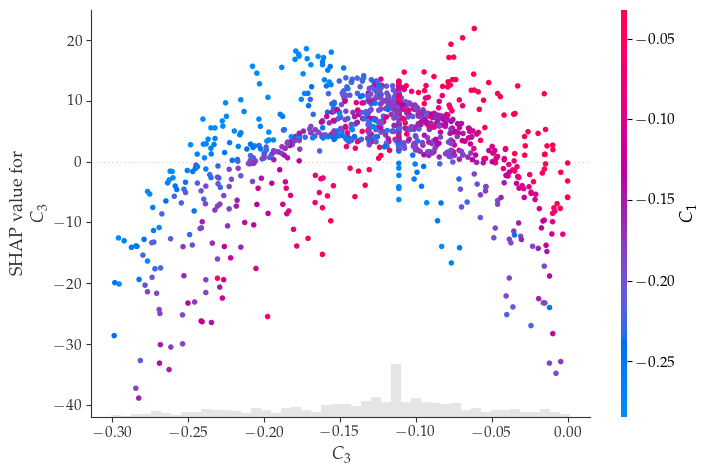

  saved: ../outputs/figures/rotBIII_shap_bq.pdf


<Figure size 640x480 with 0 Axes>

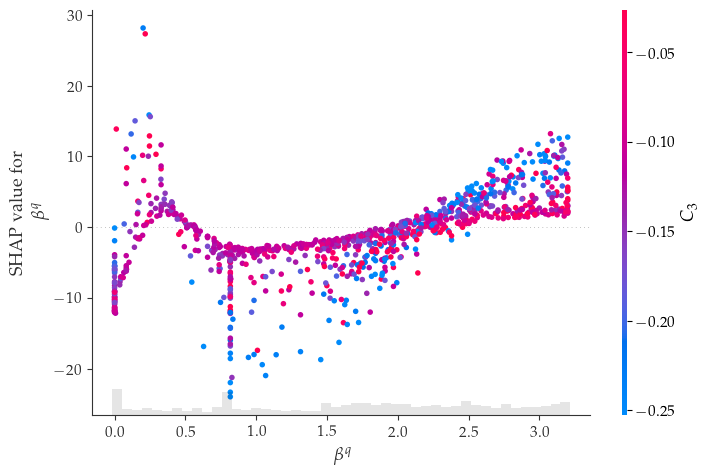

In [9]:
shap_v, X_s = shap_summary(
    model, info['X_val'],
    title='rotBIII · SMEFT19 likelihood',
    save_dir=FIGS_DIR,
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    title='rotBIII · waterfall (sample 0)',
    save_path=FIGS_DIR / 'shap_waterfall.pdf',
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGS_DIR,
    prefix='rotBIII',
    show=True,
)

## 5. Save the trained model

Persist the fitted XGBoost surrogate to disk so the downstream figures (and
other notebooks) can reload it without retraining.

In [10]:
model.save_model(MODEL_OUT)
print(f'Model saved to: {MODEL_OUT}')

Model saved to: ../outputs/xgboost_scIII.json


## 6. Figure 7 — χ² validation and Monte-Carlo distribution

Reproduces Figs. 7a and 7b of the paper:

- **7a**: scatter of predicted vs actual Δχ²_SM on the validation set — measures
  the emulator quality (with the Pearson correlation).
- **7b**: histogram of Δχ² = 2(log L_bf − log L̃) for the Monte-Carlo points vs the
  theoretical χ²(N_DOF) distribution.

**Monte-Carlo algorithm**: a **Metropolis random-walk MCMC** driven entirely by
the emulator. Each proposal is a Gaussian step from the current point with
covariance equal to the fit covariance Σ (Cholesky factor), clipped to the
physical domain, and accepted with the standard Metropolis rule
`log u < log L̃(x′) − log L̃(x)`, `u ~ U(0,1)`. After 3 000 burn-in steps, 15 000
samples are kept. **This single chain is reused in §7** for the correlation
matrix.

**Reading Fig 7b**: the χ²(3) curve is the Gaussian (Wilks) reference, not an
expectation the histogram must match. The sample follows its overall shape but
is displaced towards larger Δχ²; this is a direct imprint of the non-Gaussian
likelihood, since βq is only weakly constrained and develops an extended,
curved ridge far from a quadratic log-likelihood. A spike at Δχ² = 0 seen in
earlier versions was an emulator artifact (over-extrapolation at high βq) and
is removed by the densification step of §1.

YAML best-fit  : C1=-0.18591  C3=-0.11125  bq=0.81725
XGBoost best-fit: C1=-0.18260  C3=-0.10810  bq=0.98760
log_L_bf (XGBoost opt) = 22.4503  |  log_L at YAML bf = 20.7433
1σ (diagonal Σ):  C1=0.0325  C3=0.0221  bq=0.6421

log_L_SM (model) = -1.9593
ΔΔχ²_SM at bf    = 48.82  (best-fit improvement over SM)

Fig 7a — Pearson r = 0.9921  |  MAE = 1.8538


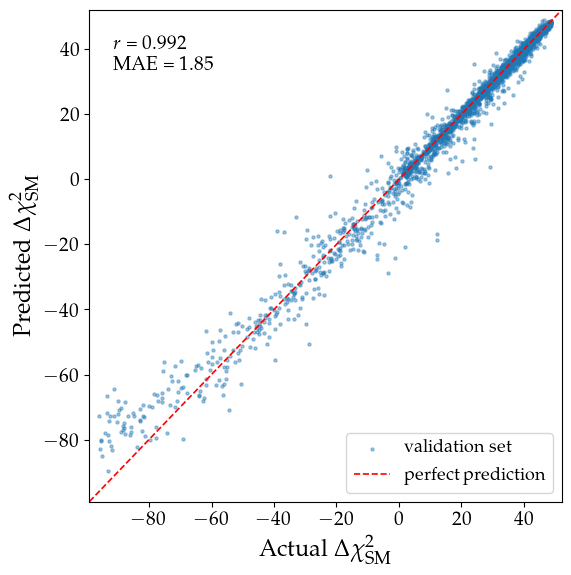

In [11]:
from scipy.stats import pearsonr
import yaml

# Load best-fit and covariance from the YAML
with open(BESTFIT_FILE) as _f:
    _ell = yaml.safe_load(_f)

bf_arr    = np.array(_ell['bf'])
_eig_vals = np.array([_ell['d'][i][i] for i in range(3)])
_V        = np.array(_ell['v'])
Sigma_bf  = _V.T @ np.diag(1.0 / _eig_vals) @ _V
_chol     = np.linalg.cholesky(Sigma_bf)

_sig    = np.sqrt(np.diag(Sigma_bf))
_lo_opt = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_opt = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

# ±1σ fine grid to locate the emulator best-fit
_lo_f   = np.maximum(bf_arr - 1.0 * _sig, _lo_opt)
_hi_f   = np.minimum(bf_arr + 1.0 * _sig, _hi_opt)
_nf    = 50
_c1f, _c3f, _bqf = np.meshgrid(np.linspace(_lo_f[0], _hi_f[0], _nf),
                                np.linspace(_lo_f[1], _hi_f[1], _nf),
                                np.linspace(_lo_f[2], _hi_f[2], _nf),
                                indexing='ij')
_fine_df  = pd.DataFrame({'C1': _c1f.ravel(), 'C3': _c3f.ravel(), 'bq': _bqf.ravel()})
_fine_pred = model.predict(_fine_df)
_bi       = int(np.argmax(_fine_pred))
log_L_bf  = float(_fine_pred[_bi])
bf_model  = np.array([float(_fine_df.iloc[_bi]['C1']),
                       float(_fine_df.iloc[_bi]['C3']),
                       float(_fine_df.iloc[_bi]['bq'])])

log_L_bf_yaml = float(model.predict(pd.DataFrame([{'C1': bf_arr[0],
                                                    'C3': bf_arr[1],
                                                    'bq': bf_arr[2]}]))[0])

print(f'YAML best-fit  : C1={bf_arr[0]:.5f}  C3={bf_arr[1]:.5f}  bq={bf_arr[2]:.5f}')
print(f'XGBoost best-fit: C1={bf_model[0]:.5f}  C3={bf_model[1]:.5f}  bq={bf_model[2]:.5f}')
print(f'log_L_bf (XGBoost opt) = {log_L_bf:.4f}  |  log_L at YAML bf = {log_L_bf_yaml:.4f}')
print(f'1σ (diagonal Σ):  C1={np.sqrt(Sigma_bf[0,0]):.4f}  '
      f'C3={np.sqrt(Sigma_bf[1,1]):.4f}  bq={np.sqrt(Sigma_bf[2,2]):.4f}')

log_L_SM = float(model.predict(pd.DataFrame([{'C1': 0., 'C3': 0., 'bq': 0.}]))[0])
print(f'\nlog_L_SM (model) = {log_L_SM:.4f}')
print(f'ΔΔχ²_SM at bf    = {2*(log_L_bf - log_L_SM):.2f}  (best-fit improvement over SM)')

# Fig 7a
y_pred_va  = model.predict(Xva)
dchi2_act  = 2.0 * (yva.values - log_L_SM)
dchi2_pred = 2.0 * (y_pred_va  - log_L_SM)

r_7a, _  = pearsonr(dchi2_act, dchi2_pred)
mae_7a   = np.mean(np.abs(dchi2_act - dchi2_pred))
print(f'\nFig 7a — Pearson r = {r_7a:.4f}  |  MAE = {mae_7a:.4f}')

_lim_lo = min(dchi2_act.min(), dchi2_pred.min()) - 3
_lim_hi = max(dchi2_act.max(), dchi2_pred.max()) + 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(dchi2_act, dchi2_pred, s=5, alpha=0.4, rasterized=True,
           label='validation set')
ax.plot([_lim_lo, _lim_hi], [_lim_lo, _lim_hi], 'r--', lw=1.2,
        label='perfect prediction')
ax.set_xlim(_lim_lo, _lim_hi)
ax.set_ylim(_lim_lo, _lim_hi)
ax.set_xlabel(r'Actual $\Delta\chi^2_{\mathrm{SM}}$')
ax.set_ylabel(r'Predicted $\Delta\chi^2_{\mathrm{SM}}$')
ax.text(0.05, 0.95, f'$r$ = {r_7a:.3f}\nMAE = {mae_7a:.2f}',
        transform=ax.transAxes, va='top', fontsize=14)
ax.legend(fontsize=13, loc='lower right')
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7a_chi2_scatter.pdf', bbox_inches='tight')
plt.show()

MCMC: 3000 burn-in + 15000 samples in 61.1s
Acceptance rate: 30.8%
Mean Dchi2_MC = 3.955  (expected chi2(3) = 3)


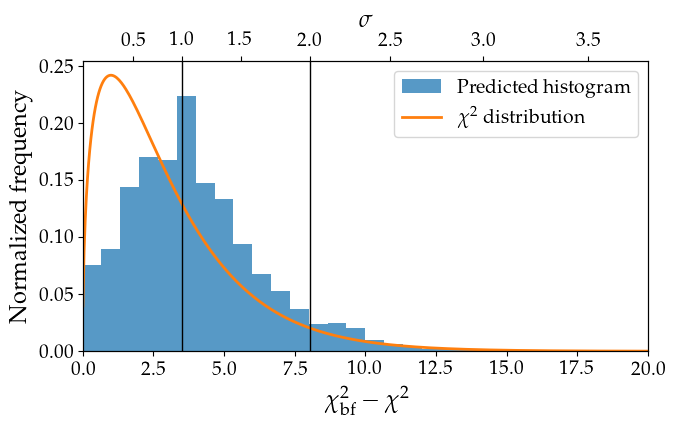

In [12]:
from scipy.stats import chi2 as chi2_dist, norm as norm_dist
import time

# Metropolis MCMC on the emulator; the chain feeds both Fig 7b and Figs 10/11.
N_MCMC_BURN = 3_000
N_MCMC_KEEP = 15_000

_rng_mc  = np.random.default_rng(SEED + 77)
_chol_s  = np.linalg.cholesky(Sigma_bf)
_lo_dom  = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_dom  = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

x_cur = bf_model.copy()
L_cur = float(model.predict(pd.DataFrame([{'C1': x_cur[0], 'C3': x_cur[1], 'bq': x_cur[2]}]))[0])

kept_X  = np.empty((N_MCMC_KEEP, 3))   # (C1, C3, bq)
kept_L  = np.empty(N_MCMC_KEEP)        # log-likelihood
n_kept  = 0
n_total = 0
n_acc   = 0
t0_mc2  = time.time()

# Burn-in
for _ in range(N_MCMC_BURN):
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop

# Sampling
while n_kept < N_MCMC_KEEP:
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    n_total += 1
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop
        n_acc += 1
    kept_X[n_kept] = x_cur
    kept_L[n_kept] = L_cur
    n_kept += 1

acc_rate   = n_acc / n_total * 100
dchi2_mc   = np.maximum(0.0, 2.0 * (log_L_bf - kept_L))
mean_dchi2 = float(np.mean(dchi2_mc))
print(f'MCMC: {N_MCMC_BURN} burn-in + {N_MCMC_KEEP} samples in {time.time()-t0_mc2:.1f}s')
print(f'Acceptance rate: {acc_rate:.1f}%')
print(f'Mean Dchi2_MC = {mean_dchi2:.3f}  (expected chi2({N_DOF}) = {N_DOF})')

# Fig 7b
x_max = 20.0
xs    = np.linspace(0.01, x_max, 500)
bins  = np.linspace(0.0, x_max, 31)

_sigma_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
_dchi2_top  = [chi2_dist.ppf(norm_dist.cdf(s) - norm_dist.cdf(-s), df=N_DOF)
               for s in _sigma_vals]
_top_ticks  = [(s, d) for s, d in zip(_sigma_vals, _dchi2_top) if d <= x_max]

_vline_1s = chi2_dist.ppf(norm_dist.cdf(1.0) - norm_dist.cdf(-1.0), df=N_DOF)
_vline_2s = chi2_dist.ppf(norm_dist.cdf(2.0) - norm_dist.cdf(-2.0), df=N_DOF)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dchi2_mc, bins=bins, density=True, alpha=0.75,
        label='Predicted histogram', color='C0')
ax.plot(xs, chi2_dist.pdf(xs, df=N_DOF), lw=2.0, color='C1',
        label=rf'$\chi^2$ distribution')
ax.axvline(_vline_1s, color='k', lw=1.0)
ax.axvline(_vline_2s, color='k', lw=1.0)
ax.set_xlim(0, x_max)
ax.set_xlabel(r'$\chi^2_{\mathrm{bf}} - \chi^2$')
ax.set_ylabel('Normalized frequency')
ax.legend()

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([d for _, d in _top_ticks])
ax2.set_xticklabels([f'{s:.1f}' for s, _ in _top_ticks])
ax2.set_xlabel(r'$\sigma$')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7b_chi2_histogram.pdf', bbox_inches='tight')
plt.show()

## 7. Figure 11 — Pearson correlation matrix of the observables

Reproduces the observable correlation matrix of the paper for the
**rotBIII / Scenario III** direction (C₁ ≠ C₃). The observables are
`BR(B⁺→Kνν)`, `BR(τ→μνν)`, `BR(K⁺→πνν)`, `BR(B⁰→μμ)`, `BR(Bs→μμ)`, `R_K*`,
`R_D`, `R_J/ψ` — plus Δχ²_SM.

> **What changes vs the Scenario II reference figure:** in Scenario III the
> `R_D ↔ BR(B⁺→Kνν)` correlation (≈ 0.99 in the C₁=C₃ scenario, where both depend
> on the same `C·λ^q₂₃·λ^ℓ₃₃`) **decorrelates**, since `BR(B⁺→Kνν) ∝ (C₁−C₃)`
> while `R_D ∝ C₃`. That is the only structural change expected; no *new*
> correlations should appear. We therefore use the **full 15 000-point chain**
> (no thinning or subsampling, which would only add statistical noise to the
> near-zero cells; the per-point work is parallelised instead).

> The WET-coefficient correlation matrix (old Fig 10) is **not** computed — it
> shared the slow per-point `match_run` loop and was dropped from the paper.

**Procedure**:
1. **Reuse** the full MCMC chain from §6 (`kept_X`/`kept_L`).
2. For each point, run SMEFT → WET (`match_run`, µ = m_b = 4.8 GeV) and evaluate
   the observables with `flavio`. This is done **in parallel** over `N_WORKERS`
   cores (SMEFT19 is initialised in the parent and inherited by the fork workers,
   the same pattern as `scripts/regenerate_dataset.py`), so the full chain runs in
   ~1–2 min instead of ~15 min serial.
3. Compute the Pearson correlation matrix, keeping only the observables that
   genuinely vary in Scenario III. There is no NP in the muon/electron sector
   (`λ^ℓ₂₂ = 0` ⇒ `C₁₀^μ = 0`, `R_K* = 1`) nor in `s → d` (`α^q = 0`), so
   `BR(Bs→μμ)`, `BR(B⁰→μμ)` and `R_K*` are SM-constant here and their
   "correlations" would be pure numerical noise; a variance filter drops them.

**R(J/ψ):** `Rtaumu(Bc->J/psilnu)` is computed directly per point thanks to the
`flavio@BctoJpsi` fork used by the `.venv-paper` environment (stock flavio has
no semileptonic `Bc→J/ψ`). In Scenario III the `b→cτν` transition is modified
only by `C_VL`, so `R(J/ψ)` and `R_D` scale by the same `|1+C_VL|²`: their
≈ 1.00 correlation is a genuine output of the fit, the physical statement that
all `b→cτν` LFU ratios move together.

> **Requires** SMEFT19, wilson and flavio installed (the earlier cells do not need
> them).

In [13]:
# Correlation-matrix sample: reuse the FULL Fig 7b MCMC chain (kept_X, kept_L).
# No thinning — all points are kept so the Pearson coefficients carry no extra
# statistical noise (the per-point work below is parallelised instead of subsampled).
N_CORR = N_MCMC_KEEP

mc_df = pd.DataFrame({
    'C1':         kept_X[:N_CORR, 0],
    'C3':         kept_X[:N_CORR, 1],
    'bq':         kept_X[:N_CORR, 2],
    'log_L_pred': kept_L[:N_CORR],
    'delta_chi2': np.maximum(0.0, 2.0 * (log_L_bf - kept_L[:N_CORR])),
})
print(f'MC sample: {len(mc_df)} MCMC points (full chain, shared with Fig 7b)')
mc_df[['C1', 'C3', 'bq', 'delta_chi2']].describe()

MC sample: 15000 MCMC points (full chain, shared with Fig 7b)


,C1,C3,bq,delta_chi2
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,-0.162007,-0.147835,1.293199,3.955037
std,0.044486,0.037396,0.884066,2.384518
min,-0.300000,-0.280609,0.121939,0.000000
25%,-0.190179,-0.173789,0.465218,2.280979
50%,-0.160079,-0.141932,1.124424,3.663910
75%,-0.128391,-0.120535,2.007021,5.123508
max,-0.046761,-0.057142,3.200000,24.312471


In [14]:
import flavio
import wilson as _wilson
import multiprocessing
import SMEFT19
_apply_paper_style()  # SMEFT19 overwrites rc params on import

# Initialize SMEFT19 + warm flavio in the PARENT; the fork workers inherit this
# state (same pattern as scripts/regenerate_dataset.py), so no per-worker re-init.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    SMEFT19.SMEFTglob.gl.make_measurement()
    _ = flavio.sm_prediction('Rtaul(B->Dlnu)')

# Observables shown in Fig 11 (Scenario III), in display order.
# R(J/psi) = Rtaumu(Bc->J/psilnu) is computed directly per point (flavio@BctoJpsi),
# like every other observable, so its correlation with R(D) is a genuine output of
# the fit rather than imposed by construction.
OBS_DEF = [
    ('BR(B+->Knunu)',    {},                            r'$\mathrm{BR}(B^+\!\to K^+\nu\bar\nu)$'),
    ('BR(tau->mununu)',  {},                            r'$\mathrm{BR}(\tau^-\!\to\mu^-\nu\bar\nu)$'),
    ('BR(K+->pinunu)',   {},                            r'$\mathrm{BR}(K^+\!\to\pi^+\nu\bar\nu)$'),
    ('BR(B0->mumu)',     {},                            r'$\mathrm{BR}(B^0\!\to\mu^+\mu^-)$'),
    ('BR(Bs->mumu)',     {},                            r'$\mathrm{BR}(B_s\!\to\mu^+\mu^-)$'),
    ('<Rmue>(B0->K*ll)', {'q2min': 1.1, 'q2max': 6.0},  r'$R_{K^*}^{[1.1,6]}$'),
    ('Rtaul(B->Dlnu)',   {},                            r'$R_D^\ell$'),
    ('Rtaumu(Bc->J/psilnu)', {},                        r'$R_{J/\psi}$'),
]


def _obs_worker(args):
    """SMEFT -> WET (match_run) -> flavio observables for one MCMC point."""
    import warnings as _w
    _w.simplefilter('ignore')
    C1, C3, bq, dchi2 = args
    try:
        w  = SMEFT19.scenarios.massrotation([C1, C3, 0.0, 0.0, 0.0, bq])
        wc = w.match_run(4.8, 'WET', 'flavio')   # returns a WCxf WC, NOT a wilson.Wilson
        # flavio needs a wilson.Wilson; rebuild from the WC dict. The WET
        # coefficients are COMPLEX, so pass them through as-is (do NOT call float()).
        wcobj = _wilson.Wilson(dict(wc.dict), scale=4.8, eft='WET', basis='flavio')
        out = {'delta_chi2': dchi2}
        for obs_name, kwargs, _lbl in OBS_DEF:
            try:
                out[obs_name] = float(flavio.np_prediction(obs_name, wcobj, **kwargs))
            except Exception:
                out[obs_name] = float('nan')
        return out
    except Exception:
        return None


args_obs = [(r['C1'], r['C3'], r['bq'], r['delta_chi2']) for _, r in mc_df.iterrows()]
print(f'Computing flavio observables for {len(args_obs)} points on {N_WORKERS} workers...')
t0o = time.time()
ctx = multiprocessing.get_context('fork')
_obs_raw = []
with ctx.Pool(N_WORKERS) as pool:
    for i, r in enumerate(pool.imap(_obs_worker, args_obs, chunksize=16), 1):
        _obs_raw.append(r)
        if i % 2000 == 0:
            print(f'  {i}/{len(args_obs)}  ({time.time()-t0o:.0f}s)')
print(f'Done in {time.time()-t0o:.0f}s')

obs_df = pd.DataFrame([r for r in _obs_raw if r is not None])
print(f'Valid rows: {len(obs_df)}/{len(args_obs)}')

Computing flavio observables for 15000 points on 23 workers...
  2000/15000  (247s)
  4000/15000  (324s)
  6000/15000  (405s)
  8000/15000  (483s)
  10000/15000  (559s)
  12000/15000  (642s)
  14000/15000  (718s)
Done in 753s
Valid rows: 15000/15000


Relative std of each observable (Scenario III):
  BR(B+->Knunu)             33.496%   keep
  BR(tau->mununu)            0.051%   drop (SM-constant in Sc III)
  BR(K+->pinunu)             1.660%   keep
  BR(B0->mumu)               0.000%   drop (SM-constant in Sc III)
  BR(Bs->mumu)               0.019%   drop (SM-constant in Sc III)
  <Rmue>(B0->K*ll)           0.008%   drop (SM-constant in Sc III)
  Rtaul(B->Dlnu)             2.267%   keep
  Rtaumu(Bc->J/psilnu)       2.267%   keep

Shown in Fig 11: ['BR(B+->Knunu)', 'BR(K+->pinunu)', 'Rtaul(B->Dlnu)', 'Rtaumu(Bc->J/psilnu)', 'delta_chi2']


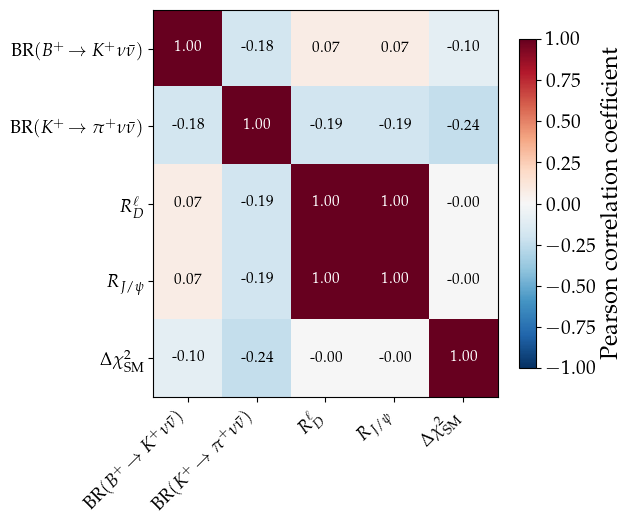

In [15]:
# Fig 11: keep only observables that genuinely vary in Scenario III (see section 7 markdown).
MIN_REL_STD = 0.01   # 1% relative std

_obs_order = [o[0] for o in OBS_DEF]
_label_map = {o[0]: o[2] for o in OBS_DEF}
_label_map['delta_chi2'] = r'$\Delta\chi^2_{\mathrm{SM}}$'

print('Relative std of each observable (Scenario III):')
_keep = []
for col in _obs_order:
    mu, sd = obs_df[col].mean(), obs_df[col].std()
    rel = sd / abs(mu) if mu != 0 else 0.0
    ok = (rel > MIN_REL_STD) and bool(obs_df[col].notna().any())
    print(f'  {col:22s}  {100*rel:8.3f}%   {"keep" if ok else "drop (SM-constant in Sc III)"}')
    if ok:
        _keep.append(col)

_obs_cols   = _keep + ['delta_chi2']
_obs_labels = [_label_map[c] for c in _obs_cols]
print(f'\nShown in Fig 11: {_obs_cols}')

_corr11 = obs_df[_obs_cols].corr(method='pearson')
_n11    = len(_obs_cols)

fig, ax = plt.subplots(figsize=(_n11 * 1.1 + 1, _n11 * 1.0 + 0.5))
im = ax.imshow(_corr11.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

ax.set_xticks(range(_n11)); ax.set_yticks(range(_n11))
ax.set_xticklabels(_obs_labels, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(_obs_labels, fontsize=13)

for i in range(_n11):
    for j in range(_n11):
        val = _corr11.iloc[i, j]
        if np.isnan(val): continue
        color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, color=color)

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig11_obs_correlations.pdf', bbox_inches='tight')
plt.show()

## 8. The ML advantage — likelihood maps and speed benchmark

A direct demonstration of the paper's central argument: **why is the emulator
needed?**

- **2D likelihood maps**: the real SMEFT19 values already exist in the dataset
  (the three 40×40 plane grids). XGBoost reproduces those maps in milliseconds,
  and it also generates dense 200×200 grids (= 40 000 evaluations) that SMEFT19
  would take days to produce.

- **Speed benchmark**: measures the actual XGBoost vs SMEFT19 wall time on a
  single thread and computes the speed-up. The SMEFT19 (exact) timing runs in a
  **cold subprocess** (empty flavio caches), so it reflects the real cost of
  generating *new* points and is not biased by caches warmed in earlier cells
  (Fig 11 evaluates flavio thousands of times). Run it on an **idle machine**
  and with the `.venv-paper` kernel: CPU contention from other processes
  inflates the exact cost.

Reference figures (paper, B-physics timing table, single core): surrogate
≈ 34 µs/eval vs exact ≈ 3.3 s/eval, a speed-up of ≈ 1.0×10⁵; generating the
≈ 2.6×10⁴-point training set costs ≈ 24 core-hours exactly, vs under a second
with the trained surrogate. Individual runs fluctuate around these values.

Plane C1-C3: SMEFT19 grid vs XGBoost emulator (40x40)
Plane C1-bq: SMEFT19 grid vs XGBoost emulator (40x40)
Plane C3-bq: SMEFT19 grid vs XGBoost emulator (40x40)


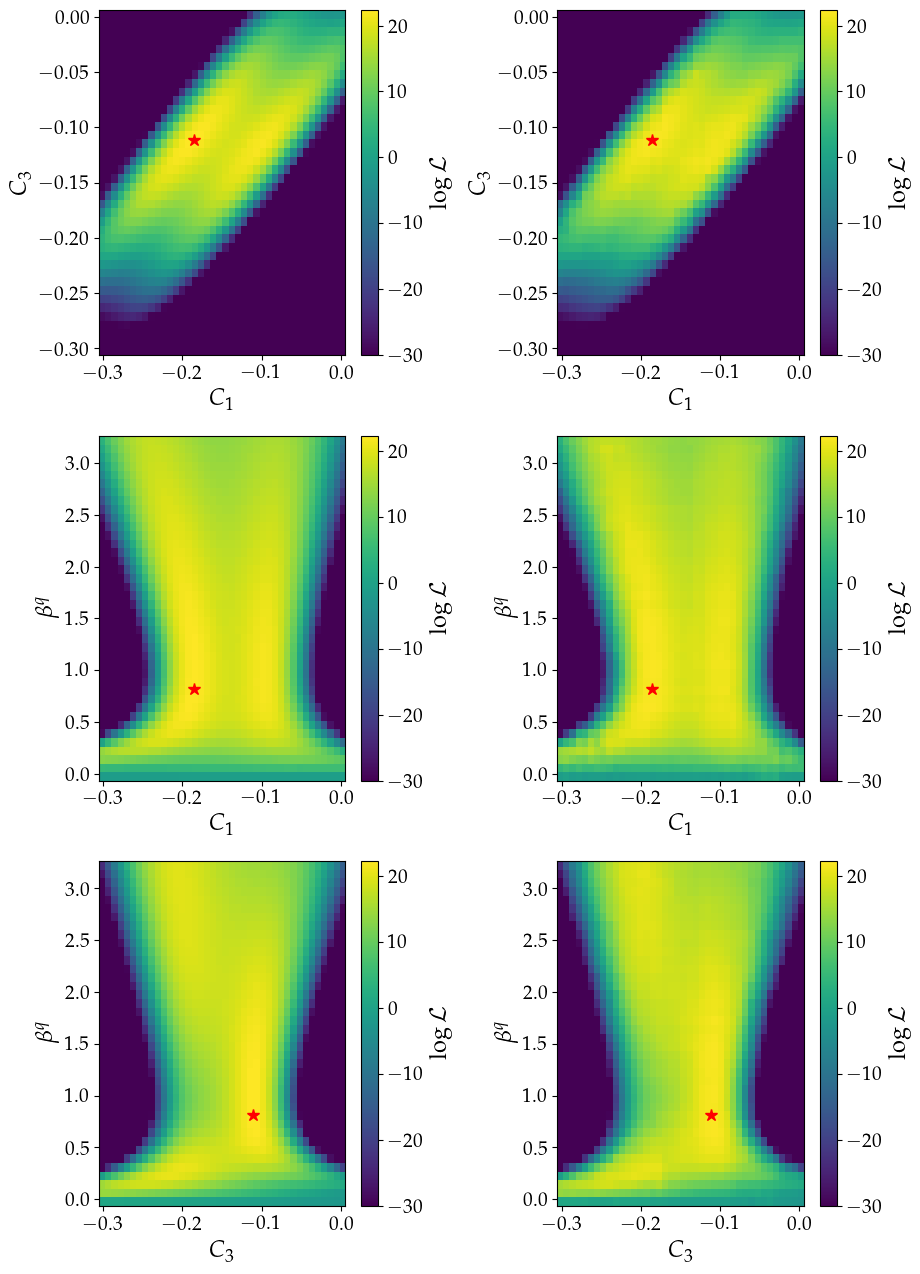

Fig 8a saved.


In [16]:
# Section 8a: 2D likelihood map - real SMEFT19 vs XGBoost emulator
_MARG  = 0.02

def _rng_ext(col):
    """Range with the same margin used for the grid points."""
    lo, hi = {'C1': C1_RANGE, 'C3': C3_RANGE, 'bq': BQ_RANGE}[col]
    m = _MARG * (hi - lo)
    return lo - m, hi + m

# The 3 plane grids are the last 3*GRID_SIZE^2 rows of the dataset
_g2 = GRID_SIZE ** 2
_base = len(df_raw) - 3 * _g2
PLANES = [
    {'cx': 'C1', 'cy': 'C3',  'cz': 'bq', 'vz': bf_arr[2],
     's0': _base,           's1': _base + _g2,
     'xl': r'$C_1$', 'yl': r'$C_3$'},
    {'cx': 'C1', 'cy': 'bq',  'cz': 'C3', 'vz': bf_arr[1],
     's0': _base + _g2,     's1': _base + 2 * _g2,
     'xl': r'$C_1$', 'yl': r'$\beta^q$'},
    {'cx': 'C3', 'cy': 'bq',  'cz': 'C1', 'vz': bf_arr[0],
     's0': _base + 2 * _g2, 's1': _base + 3 * _g2,
     'xl': r'$C_3$', 'yl': r'$\beta^q$'},
]

LH_CLIP  = -30.0
BF_COLS  = ['C1', 'C3', 'bq']

fig, axes = plt.subplots(3, 2, figsize=(9.4, 13))

for ri, p in enumerate(PLANES):
    cx, cy, cz = p['cx'], p['cy'], p['cz']
    rx, ry     = _rng_ext(cx), _rng_ext(cy)
    ext        = [rx[0], rx[1], ry[0], ry[1]]

    # Real SMEFT19 values from the dataset (GRID_SIZE x GRID_SIZE plane grid)
    grid_sl  = df_raw.iloc[p['s0']:p['s1']]
    # outer loop = cx, inner loop = cy; imshow needs [iy, ix] -> transpose
    lh_smeft = grid_sl['likelihood'].values.clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # XGBoost on the same grid points
    X_sp     = grid_sl[['C1', 'C3', 'bq']].reset_index(drop=True)
    lh_xgb_s = model.predict(X_sp).clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # Shared color scale
    vmax = float(np.nanmax(lh_smeft))
    kw   = dict(origin='lower', aspect='auto', extent=ext,
                vmin=LH_CLIP, vmax=vmax, cmap='viridis')

    bfx = bf_arr[BF_COLS.index(cx)]
    bfy = bf_arr[BF_COLS.index(cy)]

    for ci, (arr, do_T) in enumerate([(lh_smeft, True), (lh_xgb_s, True)]):
        ax = axes[ri, ci]
        im = ax.imshow(arr.T if do_T else arr, **kw)
        ax.plot(bfx, bfy, 'r*', ms=9, zorder=5, label='best fit')
        ax.set_xlabel(p['xl']); ax.set_ylabel(p['yl'])
        plt.colorbar(im, ax=ax, label=r'$\log\mathcal{L}$')

    print(f'Plane {cx}-{cy}: SMEFT19 grid vs XGBoost emulator ({GRID_SIZE}x{GRID_SIZE})')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8a_likelihood_maps.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 8a saved.')

XGBoost (1 thread): 10,000 evals in 418.1 ms -> 41.81 us/eval
SMEFT19: subproceso frio, 15 puntos frescos (~3-5 min, MAQUINA OCIOSA)...
SMEFT19 (1 thread, FRIO): 15 evals | media=3.27s med=3.28s std=0.04s min=3.19s max=3.33s | warm-up=6.0s (1x, amortizado)

========== TABLA B-anomalies (single-thread, cache fria) ==========
  Magnitud                       Surrogate          Exacto      Speed-up
  por evaluacion                   41.8 us         3.27 s       78,149x
  dataset (14,000 pts)            0.585 s      12.71 core-h       78,149x


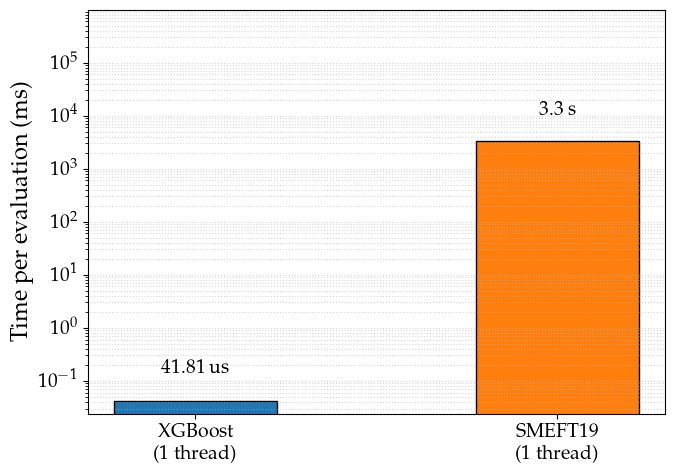

In [17]:
# Section 8b: timing benchmark — XGBoost surrogate vs exact SMEFT19 (CPU, 1 thread).
# The exact branch runs in a cold subprocess (empty caches); see markdown above.
# Requires the .venv-paper kernel and an idle machine.
import os, sys, json, time, textwrap, subprocess
import numpy as np, pandas as pd

try:
    from threadpoolctl import threadpool_limits
except Exception:
    from contextlib import contextmanager
    @contextmanager
    def threadpool_limits(*a, **k):
        yield

try:
    model.set_params(n_jobs=1)
except Exception:
    try: model.set_param({'nthread': 1})
    except Exception: pass

N_BENCH_XGB   = 10_000   # surrogate (batch)
N_BENCH_SMEFT = 15       # exact, serial, cold: ~3.3 s/eval idle; raise for more statistics
N_SCAN        = 26_000   # full training set incl. high-bq densification (~2.6e4 points)

# --- 1) XGBoost surrogate (1 thread), batch, in this kernel ---
_rng_bm = np.random.default_rng(SEED + 999)
X_bm = pd.DataFrame({
    'C1': _rng_bm.uniform(*C1_RANGE, N_BENCH_XGB),
    'C3': _rng_bm.uniform(*C3_RANGE, N_BENCH_XGB),
    'bq': _rng_bm.uniform(*BQ_RANGE, N_BENCH_XGB),
})
_ = model.predict(X_bm.iloc[:10])                      # warm-up
with threadpool_limits(1):
    t0 = time.perf_counter()
    _ = model.predict(X_bm)
    t_xgb = time.perf_counter() - t0
xgb_per_eval = t_xgb / N_BENCH_XGB
print(f'XGBoost (1 thread): {N_BENCH_XGB:,} evals in {t_xgb*1e3:.1f} ms -> {xgb_per_eval*1e6:.2f} us/eval')

# --- 2) Exact SMEFT19 in a COLD subprocess (empty caches), distinct fresh points ---
_scripts_dir = str((ROOT / 'scripts').resolve())
_child = textwrap.dedent(f'''
    import os, sys, json, time, warnings
    os.environ["OMP_NUM_THREADS"]="1"; os.environ["MKL_NUM_THREADS"]="1"; os.environ["OPENBLAS_NUM_THREADS"]="1"
    import numpy as np
    sys.path.insert(0, r"{_scripts_dir}")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        from setup_likelihood import setup_global_likelihood
        setup_global_likelihood(verbose=False)   # = what the parent does before forking
        import SMEFT19
    C1_RANGE = {tuple(map(float, C1_RANGE))}
    C3_RANGE = {tuple(map(float, C3_RANGE))}
    BQ_RANGE = {tuple(map(float, BQ_RANGE))}
    N = {int(N_BENCH_SMEFT)}
    rng = np.random.default_rng({int(SEED)} + 999)
    pts = np.column_stack([rng.uniform(*C1_RANGE, N+1),
                           rng.uniform(*C3_RANGE, N+1),
                           rng.uniform(*BQ_RANGE, N+1)])
    def chi2(row):
        C1, C3, bq = row
        try:
            return max(float(SMEFT19.likelihood_global([C1, C3, 0.0, 0.0, 0.0, bq],
                                                       SMEFT19.scenarios.massrotation)), -200.0)
        except Exception:
            return -200.0
    t0 = time.perf_counter(); chi2(pts[0]); warm = time.perf_counter()-t0   # warm-up (once, amortized)
    ts = []
    for r in pts[1:]:
        t0 = time.perf_counter(); chi2(r); ts.append(time.perf_counter()-t0)
    ts = np.array(ts)
    print(json.dumps(dict(warmup=warm, mean=float(ts.mean()), median=float(np.median(ts)),
                          std=float(ts.std()), mn=float(ts.min()), mx=float(ts.max()),
                          n=int(ts.size), n_fast=int((ts < 0.05).sum()))))
''')
print(f'SMEFT19: cold subprocess, {N_BENCH_SMEFT} fresh points (~1-2 min, idle machine)...')
_p = subprocess.run([sys.executable, "-c", _child], capture_output=True, text=True)
if _p.returncode != 0:
    print(_p.stderr[-2500:])
    raise RuntimeError("Exact-timing subprocess failed (is the kernel .venv-paper?)")
_lines = [ln for ln in _p.stdout.splitlines() if ln.strip().startswith("{")]
if not _lines:
    print(_p.stdout[-2000:]); print(_p.stderr[-2000:]); raise RuntimeError("No JSON in stdout")
_r = json.loads(_lines[-1])
smeft_per_eval = _r["mean"]
if _r["n_fast"]:
    print(f"  [!] {_r['n_fast']} calls <0.05s -> possible cache hits")
print(f'SMEFT19 (1 thread, COLD): {_r["n"]} evals | mean={smeft_per_eval:.2f}s '
      f'med={_r["median"]:.2f}s std={_r["std"]:.2f}s min={_r["mn"]:.2f}s max={_r["mx"]:.2f}s '
      f'| warm-up={_r["warmup"]:.1f}s (once, amortized)')

# --- 3) Summary table (single thread, cold cache) ---
speedup = smeft_per_eval / xgb_per_eval
print('\n========== B-anomalies TIMING (single thread, cold cache) ==========')
print(f"  {'Quantity':<26}{'Surrogate':>14}{'Exact':>16}{'Speed-up':>14}")
print(f"  {'per evaluation':<26}{xgb_per_eval*1e6:>11.1f} us{smeft_per_eval:>13.2f} s{speedup:>13,.0f}x")
print(f"  {f'dataset ({N_SCAN:,} pts)':<26}{N_SCAN*xgb_per_eval:>11.3f} s"
      f"{N_SCAN*smeft_per_eval/3600:>11.2f} core-h{speedup:>13,.0f}x")

# --- 4) Bar chart (per-eval, 1 thread) ---
labels = ['XGBoost\n(1 thread)', 'SMEFT19\n(1 thread)']
t_ms   = [xgb_per_eval * 1e3, smeft_per_eval * 1e3]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, t_ms, color=['C0', 'C1'], edgecolor='k', width=0.45)
ax.set_yscale('log'); ax.set_ylabel('Time per evaluation (ms)')
ax.grid(True, axis='y', which='both', ls=':', alpha=0.5)
for bar, val in zip(bars, t_ms):
    lbl = f'{val*1000:.2f} us' if val < 1 else (f'{val:.0f} ms' if val < 1000 else f'{val/1000:.1f} s')
    ax.text(bar.get_x()+bar.get_width()/2, val*2.5, lbl, ha='center', va='bottom',
            fontsize=14, fontweight='bold')
ax.set_ylim(top=max(t_ms)*300)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8b_speed_benchmark.pdf', bbox_inches='tight')
plt.show()